In [29]:
import cv2 as cv
import numpy as np
import os
import matplotlib.pyplot as plt
from PIL import Image
from IPython.display import display

# Exercício 1


uint8
(512, 512, 3)


(np.float64(-0.5), np.float64(511.5), np.float64(511.5), np.float64(-0.5))

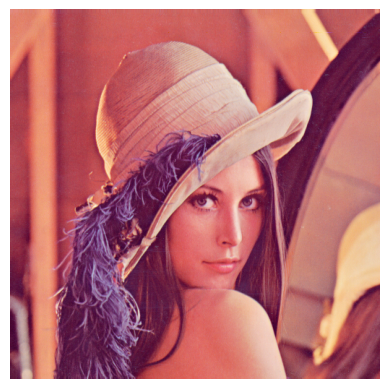

In [30]:
x_img = cv.imread ("lena.tif")
x_img_converted = cv.cvtColor(x_img, cv.COLOR_BGR2RGB)

print(x_img.dtype)
print(x_img.shape)

plt.imshow(x_img_converted)
plt.axis('off')

O método 'dtype' serve para verificar o tipo de dado da variável (exemplo: uint8, String, float).
O método 'shape' serve para mostrar as linhas, colunas e canais da imagem, neste caso, é uma imagem com: 512x512 com 3 canais (RGB)

# Exercício 2

In [31]:
cv.imwrite("file1.jpg" , x_img,(cv.IMWRITE_JPEG_QUALITY, 80))
cv.imwrite("file2.jpg" , x_img,(cv.IMWRITE_JPEG_QUALITY, 10))

True

(np.float64(-0.5), np.float64(511.5), np.float64(511.5), np.float64(-0.5))

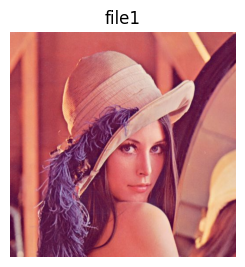

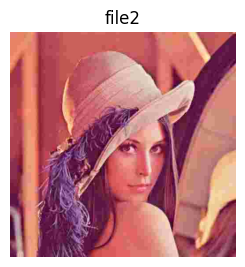

In [32]:
cnvrt = cv.cvtColor(cv.imread("file1.jpg"), cv.COLOR_BGR2RGB)
plt.figure()
plt.subplot(1,2,1)
plt.title("file1")
plt.imshow(cnvrt)
plt.axis("off")

cnvrt2 = cv.cvtColor(cv.imread("file2.jpg"), cv.COLOR_BGR2RGB)
plt.figure()
plt.subplot(1,2,1)
plt.title("file2")
plt.imshow(cnvrt2)
plt.axis("off")

In [33]:
# Converter as duas imagens para float
Ic = x_img * 1.0
Id = cv.imread("file1.jpg") * 1.0

In [ ]:
Porg = np.mean(Ic**2)
Perr = np.mean((Ic - Id)**2)
SNR = 10 * np.log10(Porg / Perr)
print(SNR.dtype)
print('SNR (dB): ', SNR)

""""
Porg (Potência do Sinal Original)
Perr (Potência do Erro ou Ruído)
SNR (Signal-to-Noise Ratio)//Relação Sinal-Ruído
Quanto maior o SNR, melhor
"""

float64
SNR (dB):  28.468534958720454


In [ ]:
PSNR = 10 * np.log10((255**2) / Perr)
print(PSNR.dtype)
print('PSNR (dB): ', PSNR)

"""
PSNR (Peak Signal-to-Noise Ratio ou Relação Sinal-Ruído de Pico) é uma variação do SNR 
focada especificamente em imagens digitais.
Enquanto o SNR usa a potência média do sinal original, 
o PSNR usa o valor máximo possível que um pixel pode ter.
"""


float64
PSNR (dB):  33.606097256534746


## Ex 3

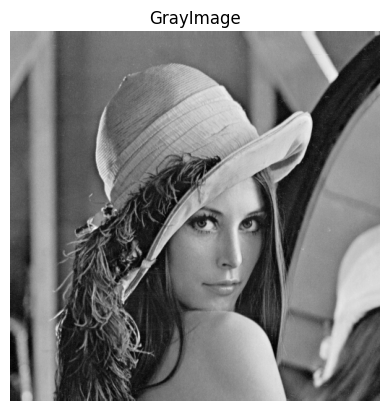

True

In [36]:
x_img_g = cv.cvtColor(x_img, cv.COLOR_BGR2GRAY)

plt.imshow(x_img_g, cmap='gray')
plt.title("GrayImage")
plt.axis("off")
plt.show()

cv.imwrite("file3.bmp", x_img_g)



In [37]:
x_img_g = os.path.getsize("./file3.bmp")
x_img_original = os.path.getsize("./lena.tif")
print("Tamanho do arquivo original: ", x_img_original, "bytes")
print("Tamanho do arquivo convertido: ", x_img_g, "bytes")
print("Redução de tamanho: ", x_img_original - x_img_g, "bytes")

Tamanho do arquivo original:  786572 bytes
Tamanho do arquivo convertido:  263222 bytes
Redução de tamanho:  523350 bytes


## EX:4

/tmp/ipykernel_6623/4106981430.py:4: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.10; the parameter will become keyword-only in 3.12.
  hist_values = plt.hist(x_img_g.ravel(), 256, [0,256])


Histograma: 3
Níveis de cinzento: 215


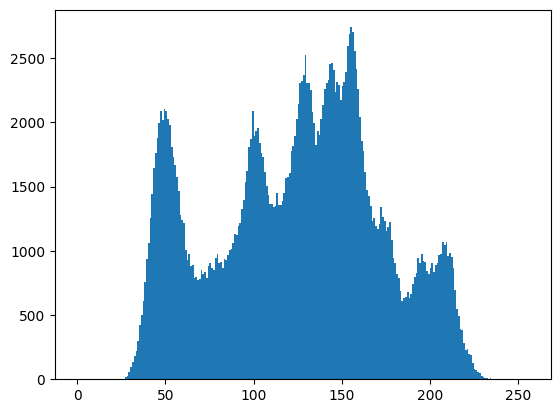

In [ ]:
x_img = cv.imread("lena.tif")
x_img_g = cv.cvtColor(x_img, cv.COLOR_BGR2GRAY)

hist_values = plt.hist(x_img_g.ravel(), 256, [0,256])

print("Histograma:", len(hist_values))

#Conta quantos tons de cinza diferentes existem realmente na imagem.
niveis_cinza = np.sum(hist_values[0] != 0)
print("Níveis de cinzento:", niveis_cinza)

""""
histograma é uma representação gráfica da distribuição de intensidades de uma imagem
"""

# Exercício 5

(np.float64(-0.5), np.float64(511.5), np.float64(511.5), np.float64(-0.5))

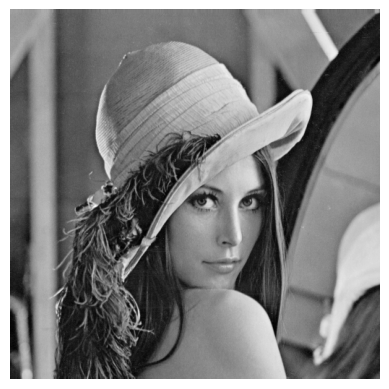

In [39]:
# grayscale
x_img_g = cv.cvtColor(x_img, cv.COLOR_BGR2GRAY)
plt . imshow (x_img_g , cmap = 'gray')
plt.axis('off')

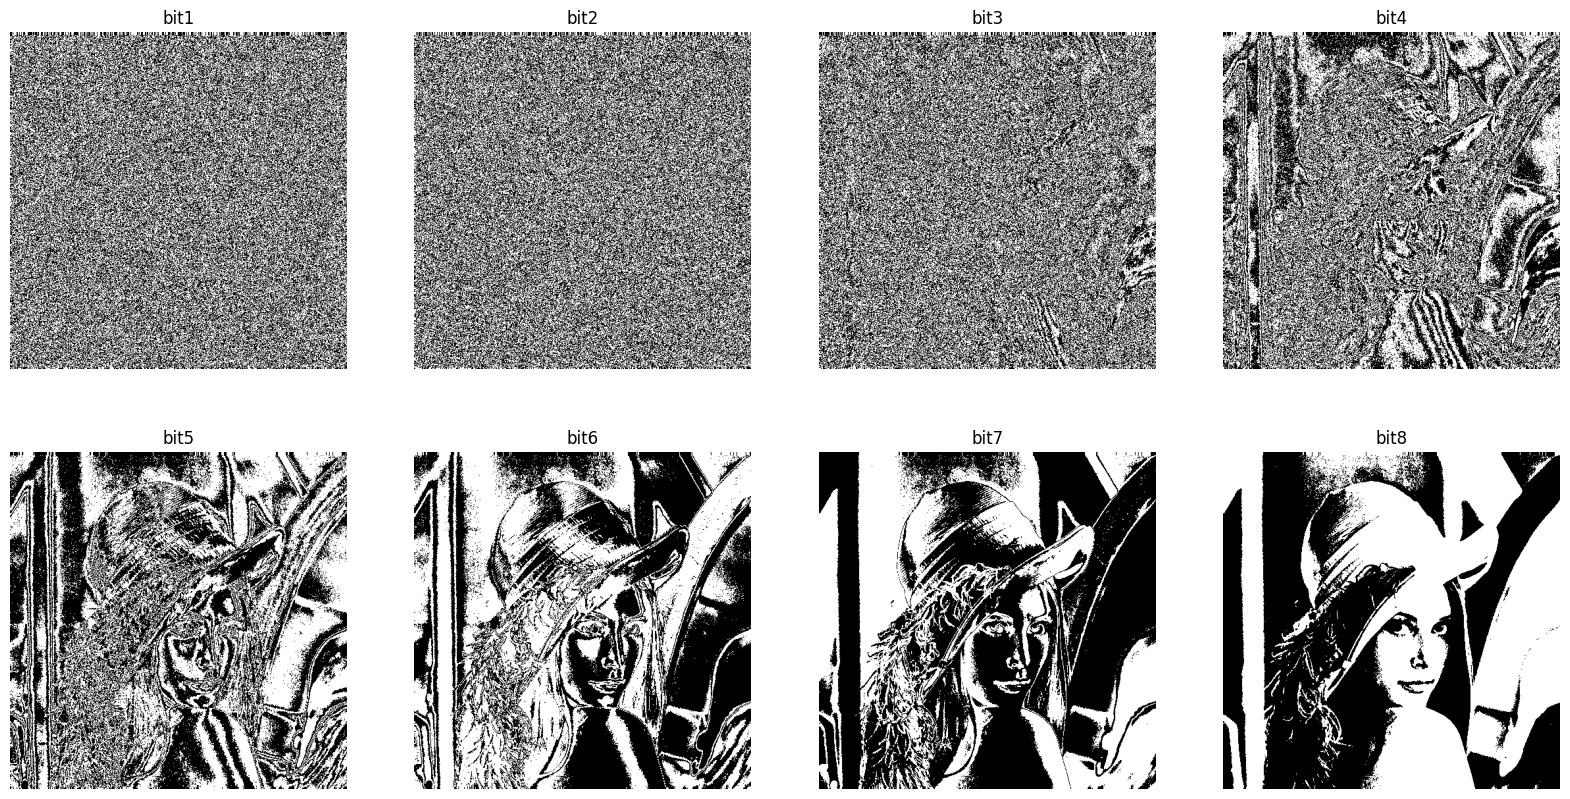

In [ ]:
plt.figure(figsize=(20, 10))

for i in range(8):  
    plt.subplot(2, 4, i+1)  
    #Empurra os bits para a direita i vezes (Bitwise Right Shift (Deslocamento de Bits para a Direita))
    I = ((x_img_g >> i) % 2) * 255
    plt.imshow(I, cmap='gray')
    plt.axis('off')
    plt.title(f'bit{i+1}')

plt.show()

# Exercício 6

In [ ]:
"""
O objetivo é converter uma imagem com muitas cores (ou tons de cinza)
para uma imagem com pouquíssimas cores (preto e branco puro) sem perder o detalhe visual 
e a percepção de profundidade.
"""

def dither(x_img_g):
    img = x_img_g * 1.0
    h, w = img.shape

    for y in range(h):
        for x in range(w):
            old_pixel = img[y, x]
            
            new_pixel = 255 if old_pixel > 127.5 else 0
            img[y, x] = new_pixel
            
            quant_error = old_pixel - new_pixel
        
            if x + 1 < w:
                img[y, x+1] += quant_error * 7/16
            
            if y + 1 < h and x - 1 >= 0:
                img[y+1, x-1] += quant_error * 3/16
                
            if y + 1 < h:
                img[y+1, x] += quant_error * 5/16
                
            if y + 1 < h and x + 1 < w:
                img[y+1, x+1] += quant_error * 1/16

    return img.astype(np.uint8)

(np.float64(-0.5), np.float64(511.5), np.float64(511.5), np.float64(-0.5))

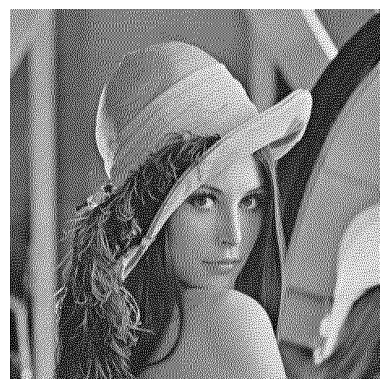

In [ ]:
dithered_img = dither(x_img_g)

plt.figure()
plt.imshow(dithered_img, cmap='gray')
plt.axis('off')

## EX: 7

In [ ]:
def save_binary(matrix, filename):
    matrix = matrix.astype(np.uint8)
    with open(filename, "wb") as f:
        matrix.tofile(f)


In [ ]:
# ---------- guardar ficheiros ----------
save_binary(x_img_g, "original.bin")
save_binary(dithered_img, "dithered.bin")

# ---------- tamanhos ----------
size_original = os.path.getsize("original.bin")
size_final = os.path.getsize("dithered.bin")

print("Tamanho original:", size_original, "bytes")
print("Tamanho final:", size_final, "bytes")

# ---------- taxa de compressão ----------
compression_ratio = size_original / size_final
print("Taxa de compressão:", compression_ratio)


Tamanho original: 262144 bytes
Tamanho final: 262144 bytes
Taxa de compressão: 1.0


In [ ]:

Ic_g = x_img_g * 1.0
Id_g = dithered_img * 1.0

Prog_g = np.mean(Ic_g **2 )
Perr_g = np.mean((Ic_g - Id_g)**2)

SNRG = 10 * np.log10(Prog_g/Perr_g)
print("SNR (dB):", SNRG)

PSNRG = 10 * np.log10((255**2) / Perr_g)
print("PSNR (dB):", PSNRG)

SNR (dB): 1.0493877429692648
PSNR (dB): 6.705809957894219


## EX: 8

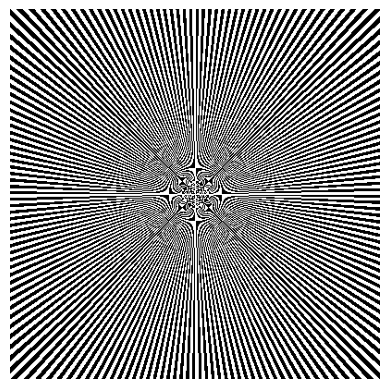

array([[  0, 255, 255, ...,   0,   0,   0],
       [  0,   0, 255, ...,   0,   0,   0],
       [  0,   0,   0, ...,   0,   0, 255],
       ...,
       [255, 255, 255, ...,   0,   0,   0],
       [255, 255,   0, ..., 255,   0,   0],
       [255,   0,   0, ..., 255, 255,   0]], shape=(400, 400), dtype=uint8)

In [ ]:

def sqtgray(N, angulo_setor):
    img = np.zeros((N, N), dtype=np.uint8)
    #centro
    cx = N / 2
    cy = N / 2
    
    for i in range(N): #
        for j in range(N):
            x = i - cx
            y = j - cy
            teta = np.arctan2(y, x)
            graus = (teta * 180 / np.pi) % 360
            setor = int(graus / angulo_setor)
            
            if setor % 2 == 0:
                img[i, j] = 255  # Branco
            else:
                img[i, j] = 0    # Preto
    
    plt.imshow(img, cmap='gray')
    plt.axis('off')
    plt.show()
    
    return img


sqtgray(400, 1)

## 9

Dimensões: (283, 900)
Tipo dos elementos: uint8


/tmp/ipykernel_6623/2963601528.py:8: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.10; the parameter will become keyword-only in 3.12.
  plt.hist(img_gray.ravel(), 256, [0, 256])
/tmp/ipykernel_6623/2963601528.py:15: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.10; the parameter will become keyword-only in 3.12.
  plt.hist(img_quant.ravel(), 2, [0, 2])


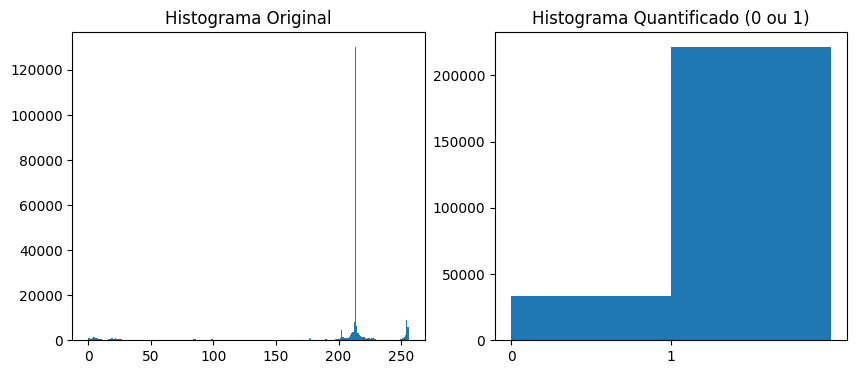

Preto e Branco:


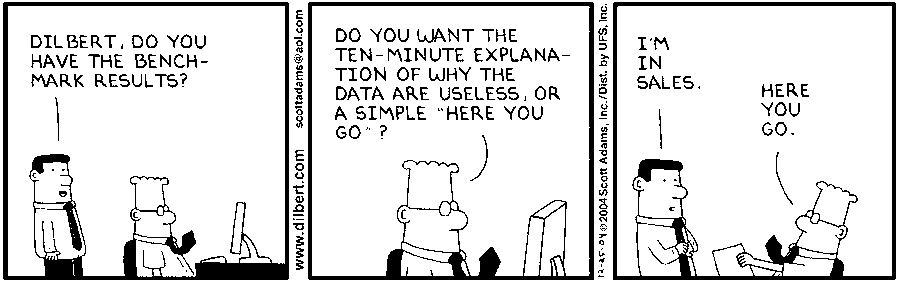

In [ ]:
img_gray = cv.imread("xpto3.jpeg", 0)

print(f"Dimensões: {img_gray.shape}")
print(f"Tipo dos elementos: {img_gray.dtype}")

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.hist(img_gray.ravel(), 256, [0, 256])
plt.title("Histograma Original")

img_scaled = img_gray / 255.0
img_quant = np.where(img_scaled > 0.5, 1, 0).astype(np.uint8)

plt.subplot(1, 2, 2)
plt.hist(img_quant.ravel(), 2, [0, 2])
plt.title("Histograma Quantificado (0 ou 1)")
plt.xticks([0, 1])
plt.show()

img_final_display = (img_quant * 255).astype(np.uint8)

print("Preto e Branco:")
img_pil = Image.fromarray(img_final_display, mode='L')
display(img_pil)



In [ ]:
f = 0.1
# se for 1, o bit inverte
#* serve para "abrir" a tupla do shape.
noise_mask = np.random.rand(*img_quant.shape) < f
#img_ruidosa = np.logical_xor(img_quant, noise_mask).astype(np.uint8)
img_ruidosa = np.where(noise_mask,1-img_quant, img_quant)
# CALCULAR O BER REAL (Comparar original vs ruidosa)
# O BER é a média de bits diferentes
ber_real = np.mean(img_quant != img_ruidosa)

print(f"Taxa de Erro (f) teórica: {f}")
print(f"Taxa de Erro (BER) real medida: {ber_real:.4f}")


Taxa de Erro (f) teórica: 0.1
Taxa de Erro (BER) real medida: 0.1002


# 9.2 

## 2

## i

In [ ]:
#Ruído de Inversão de Bit ( flip) 
fs = [0.001, 0.005, 0.01, 0.05, 0.1, 0.2, 0.3, 0.4, 0.5]
resultados = {}
for f in fs:
    noise_mask = np.random.rand(*img_quant.shape) < f
    img_ruidosa = np.where(noise_mask, 1 - img_quant, img_quant).astype(np.uint8)
    ber_real = np.mean(img_quant != img_ruidosa)

    resultados[f] = img_ruidosa
    print(f"Probabilidade f: {f:<6} | BER Real medida: {ber_real:.5f}")
  
"""
np.where funciona como if, Se noise_mask for true, flip ; se for false permanece
"""

Probabilidade f: 0.001  | BER Real medida: 0.00097
Probabilidade f: 0.005  | BER Real medida: 0.00492
Probabilidade f: 0.01   | BER Real medida: 0.00990
Probabilidade f: 0.05   | BER Real medida: 0.05019
Probabilidade f: 0.1    | BER Real medida: 0.09982
Probabilidade f: 0.2    | BER Real medida: 0.19934
Probabilidade f: 0.3    | BER Real medida: 0.30013
Probabilidade f: 0.4    | BER Real medida: 0.40107
Probabilidade f: 0.5    | BER Real medida: 0.50024


## ii

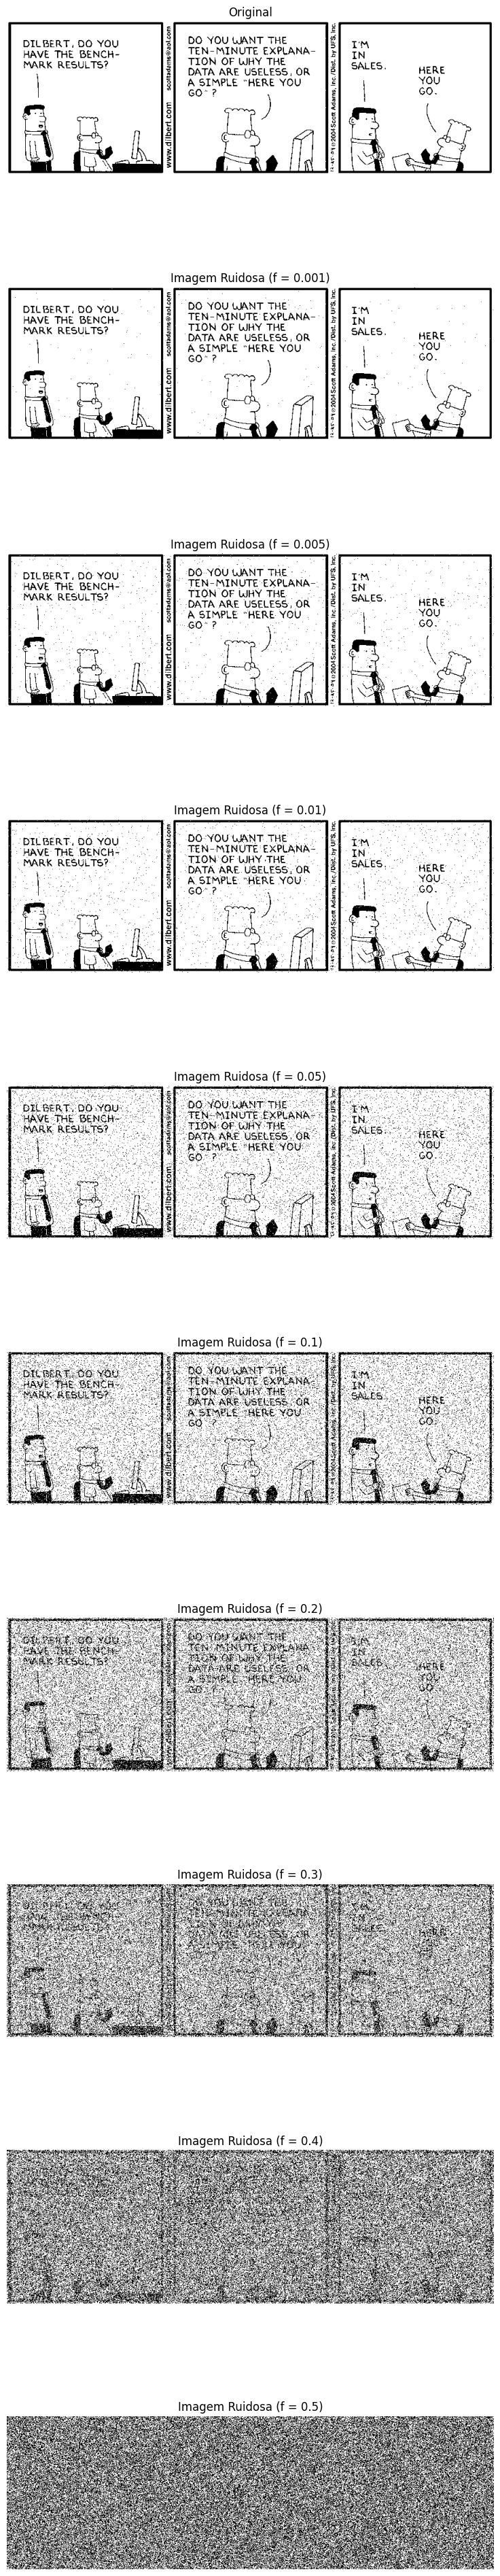

In [ ]:
plt.figure(figsize=(8, 40))

#  Mostrar a imagem original (referência)
plt.subplot(10, 1, 1) 
img_orig_disp = (img_quant * 255).astype(np.uint8)
plt.imshow(img_orig_disp, cmap='gray')
plt.title("Original", fontsize=12)
plt.axis('off')

# Loop para as ruidosas
for i in range(len(fs)): 
    f_atual = fs[i]
    img = resultados[f_atual]
    
    plt.subplot(10, 1, i +2) 
    
    img_display = (img * 255).astype(np.uint8)
    plt.imshow(img_display, cmap='gray')
    plt.title(f"Imagem Ruidosa (f = {f_atual})", fontsize=12)
    plt.axis('off')

plt.tight_layout(pad=3.0)
plt.show()

## III

In [ ]:
"""
N é o nº de vezes que cada bit da imagem é repetido
Para N = 3, o tamanho da imagem iria triplicar já que cada bit é repetido 3 vezes
"""


'\nN é o nº de vezes que cada bit da imagem é repetido\nPara N = 3, o tamanho da imagem iria triplicar já que cada bit é repetido 3 vezes\n'

In [ ]:

N = 61          # número de repetições
f = 0.5      # probabilidade de erro

canal = img.flatten()
img_o = img_quant.flatten()



"""
# Mapa de erro original (0 ou 1)
mapa_erro = (canal != img_o).astype(int)
mapa_erro=mapa_erro.flatten()
"""
# Expande os bits do canal (código de repetição)
bits_repetidos = np.repeat(canal, N)

# Aplica ruído
ruido = np.random.rand(len(bits_repetidos)) < f
bits_ruidosos = np.mod(bits_repetidos + ruido, 2)

bits_repetidos = np.array(bits_repetidos)

s = canal
t = bits_repetidos

n = np.mod(t + ruido, 2).astype(int)
# r = soma t + n
r = t ^ n

# Agrupa de N em N para votar
blocos = r.reshape(-1, N)

# Voto majoritário
decodificado = (np.sum(blocos, axis=1) > N/2).astype(int)

print(f"s: {canal}")
print(f"t: {bits_repetidos}")
print(f"n: {n}")
print("-------------------------------")
print(f"r: {r}")

print(f"s2:{decodificado}")


erros = np.sum(decodificado != img_o)
ber = erros / len(img_o)
print(f"N={N} → BER decodificado = {ber:.4f}")


s: [0 0 0 ... 1 0 0]
t: [0 0 0 ... 0 0 0]
n: [1 0 0 ... 1 1 1]
-------------------------------
r: [1 0 0 ... 1 1 1]
s2:[1 1 1 ... 0 1 1]
N=61 → BER decodificado = 0.4998


BER: 0.001452689438555163


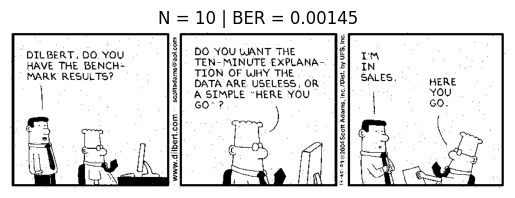

In [ ]:
N = 10            # número de repetições
f = 0.1           # probabilidade de erro 


bits_originais = img_quant.flatten()


#  CODIFICAÇÃO (repetição)
bits_transmitidos = np.repeat(bits_originais, N)


#  CANAL COM RUÍDO
ruido = np.random.rand(len(bits_transmitidos)) < f #gera um número aleatório para cada bit

bits_com_ruido = np.where(ruido, 1 - bits_transmitidos, bits_transmitidos)


#  (votação)
grupos = bits_com_ruido.reshape(-1, N) # Agrupa os N bits repetidos

votos = np.sum(grupos, axis=1) # Soma quantos '1's existem em cada grupo


bits_recuperados = (votos > (N / 2)).astype(np.uint8)

ber = np.mean(bits_originais != bits_recuperados)
print(f"BER: {ber}")
#  Reconstruir imagem
img_corrigida = bits_recuperados.reshape(img_quant.shape)

plt.imshow(img_corrigida * 255, cmap='gray')
plt.title(f"N = {N} | BER = {ber:.5f}")
plt.axis('off')
plt.show()

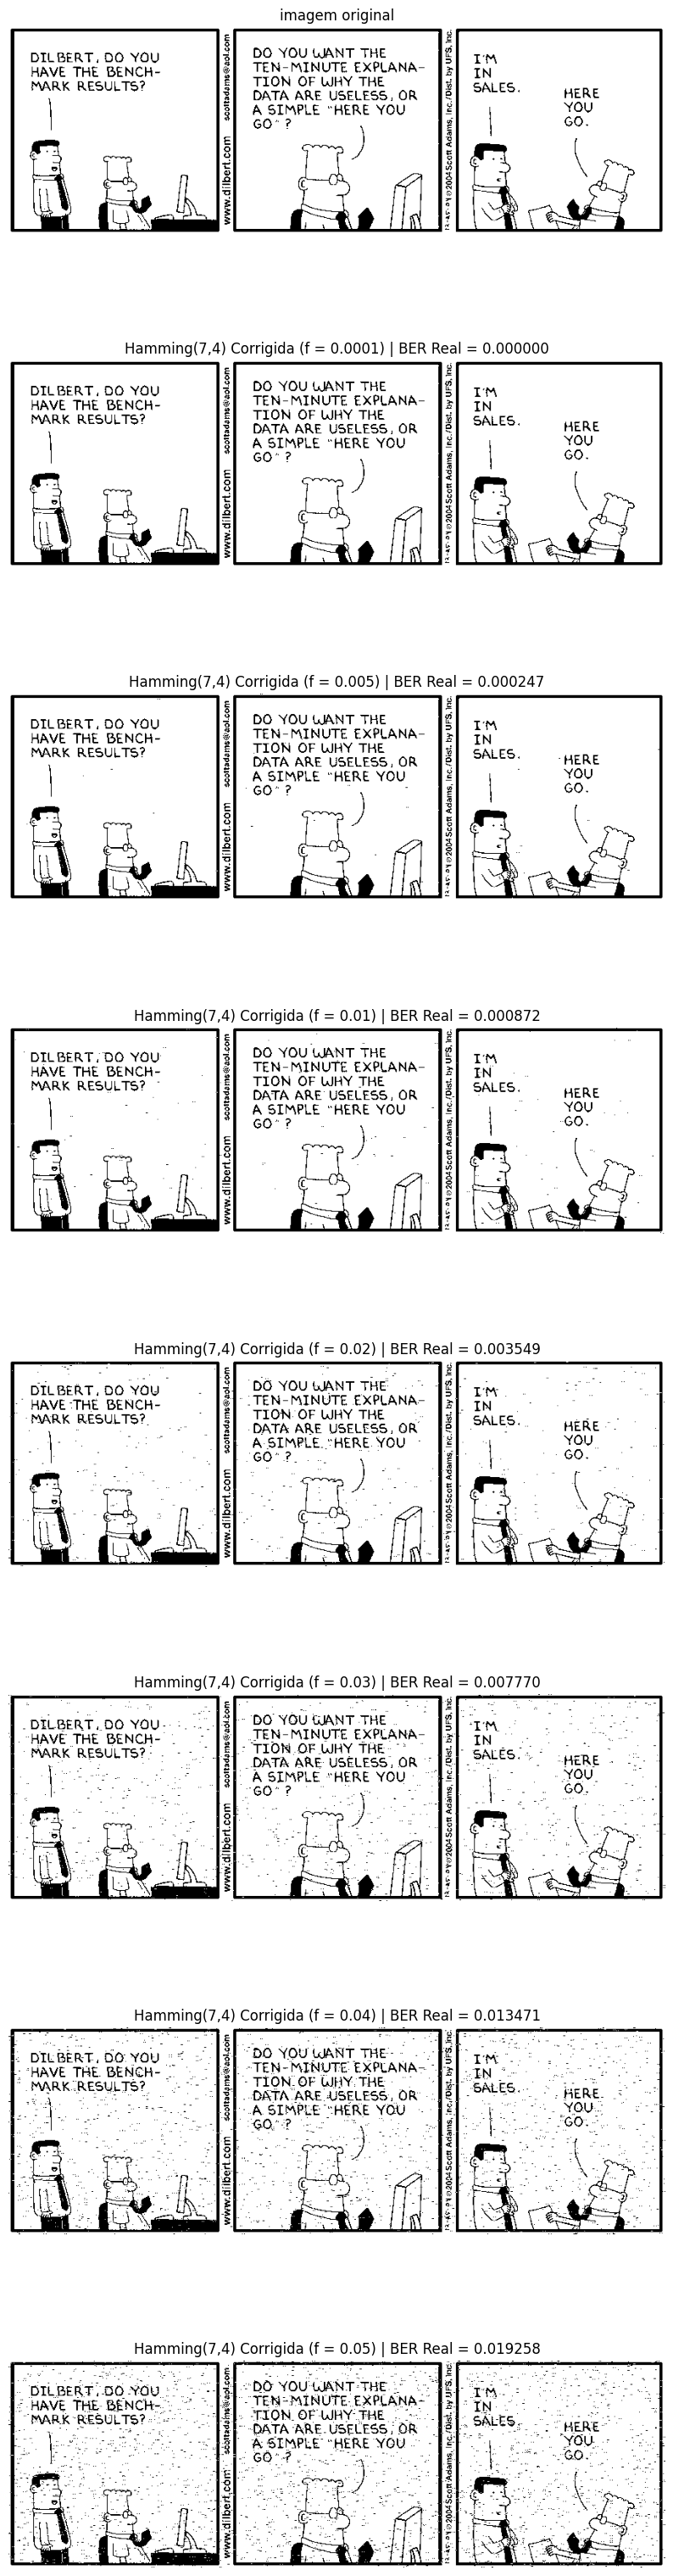

In [43]:
# definição das matrizes
G = np.array([[1,0,0,0,1,1,0],[0,1,0,0,1,0,1],[0,0,1,0,0,1,1],[0,0,0,1,1,1,1]], dtype=np.uint8)
H = np.array([[1,1,0,1,1,0,0],[1,0,1,1,0,1,0],[0,1,1,1,0,0,1]], dtype=np.uint8)
# dicionário de síndromes
tabela_erros = {(1,1,0):0, (1,0,1):1, (0,1,1):2, (1,1,1):3, (1,0,0):4, (0,1,0):5, (0,0,1):6}

def codigohamming(img_ref, f):

    bits = img_ref.flatten().astype(np.uint8)
    padding = (4 - len(bits) % 4) % 4
    bits_padded = np.append(bits, np.zeros(padding, dtype=np.uint8))
    

    blocos_4 = bits_padded.reshape(-1, 4)
    codificado = np.dot(blocos_4, G) % 2 # produto matricial
    
    # canal ruidoso (cria ruido caso um valor aleatório seja inferior à probabilidade de erro)
    ruido = (np.random.rand(*codificado.shape) < f).astype(np.uint8)
    recebido = (codificado + ruido) % 2
    
    sindromes = np.dot(recebido, H.T) % 2 
    corrigido = recebido.copy()
    for i, s in enumerate(sindromes):
        s_tuple = tuple(s)
        if s_tuple in tabela_erros:
            idx = tabela_erros[s_tuple]
            corrigido[i, idx] = 1 - corrigido[i, idx]
    
   
    bitsfinal = corrigido[:, :4].flatten()
    if padding > 0: bitsfinal = bitsfinal[:-padding]
    
    #calculo da bit error rate
    ber = np.mean(bitsfinal != bits)
    return bitsfinal.reshape(img_ref.shape), ber


fs = [0.0001, 0.005, 0.01, 0.02, 0.03, 0.04, 0.05] # lista de probabilidades de erro

plt.figure(figsize=(10, 40))

plt.subplot(len(fs) + 1, 1, 1)
img_orig_disp = (img_quant * 255).astype(np.uint8)
plt.imshow(img_orig_disp, cmap='gray')
plt.title("imagem original")
plt.axis('off')

# loop para plot das imagens
for i in range(len(fs)):
    f_atual = fs[i]
    
    # Aplicar código Hamming
    img_corr, ber_real = codigohamming(img_quant, f_atual)
    
    plt.subplot(len(fs) + 1, 1, i + 2)
    
    img_display = (img_corr * 255).astype(np.uint8)
    plt.imshow(img_display, cmap='gray')
    plt.title(f"Hamming(7,4) Corrigida (f = {f_atual}) | BER Real = {ber_real:.6f}", fontsize=12)
    plt.axis('off')
plt.show()